
# Demo of DBSCAN clustering algorithm

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds core
samples in regions of high density and expands clusters from them. This
algorithm is good for data which contains clusters of similar density.

See the `sphx_glr_auto_examples_cluster_plot_cluster_comparison.py` example
for a demo of different clustering algorithms on 2D datasets.


## Data generation

We use :class:`~sklearn.datasets.make_blobs` to create 3 synthetic clusters.



In [1]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

We can visualize the resulting data:



[[ 0.49426097  1.45106697]
 [-1.42808099 -0.83706377]
 [ 0.33855918  1.03875871]
 ...
 [-0.05713876 -0.90926105]
 [-1.16939407  0.03959692]
 [ 0.26322951 -0.92649949]]


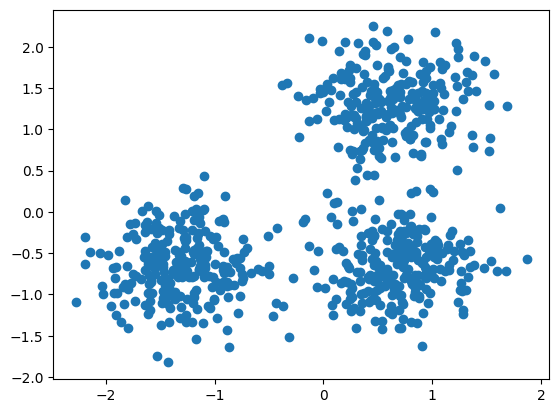

In [7]:
import matplotlib.pyplot as plt

print(X)
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [4]:
import gym
from gym.wrappers import AtariPreprocessing
from VAE.atari.utils import load_ae_model
env = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
env = AtariPreprocessing(env)

model = load_ae_model(env, "/home/sara/repositories/player_model_dt/VAE/atari/models/incentives_dataset_model/atari-100.pt")

In [5]:
! pip install numpy==1.23.1

In [167]:
import torch
import numpy
import tqdm 

def play_policy(env, model, num_eval=200, traj_length=10, tanh=True):
    model.eval()
    rewards = []
    latents = []
    data = []
    # for i in range(num_eval):
    for i in tqdm.tqdm(range(num_eval)):
        state = env.reset()
        state = torch.FloatTensor(state[0]).unsqueeze(0).unsqueeze(0)
        latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        latents.append(latent[0])
        d = {"latent": latent[0]}
        done = False
        reward = 0
        num_steps = 0
        actions = []
        while not done:
            # latents.append(latent[0])
            if tanh:
                latent = torch.tanh(latent)
            for t in range(traj_length):
                action, _ = model.decoder.act(latent, state, encode_state=True)
                action = action.cpu().numpy().flatten()[0]
                actions.append(action)
                s, r, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                reward += r
                num_steps += 1
                state = torch.FloatTensor(s).unsqueeze(0).unsqueeze(0)
                latent, _ = model.prior.act(latent=None, state=state, encode_state=True)
        actions_freq = {f"action_{i}":actions.count(i)/len(actions) for i in set(actions)}

        d.update(actions_freq)
        data.append(d)
        rewards.append(reward)
    print(numpy.mean(rewards))
    return rewards, latents, data

In [168]:
import pandas
rewards, X, data = play_policy(env, model)
X = numpy.array(X)
df = pandas.DataFrame(data)
df = df.fillna(0)

df

100%|██████████| 200/200 [24:13<00:00,  7.27s/it]

21.9


,latent,action_0,action_1,action_2,action_3,action_4,action_5
0,"[tensor(0.0240), tensor(0.0349), tensor(-0.0069), tensor(-0.0001), tensor(0.0397), tensor(0.0003), tensor(0.0340), tensor(-0.0068)]",0.972222,0.001389,0.023611,0.001389,0.001389,0.000000
1,"[tensor(-0.0581), tensor(-0.0569), tensor(0.0699), tensor(-0.0247), tensor(-0.0016), tensor(-0.0451), tensor(0.0616), tensor(-0.0350)]",0.925000,0.014583,0.027083,0.000000,0.033333,0.000000
2,"[tensor(0.0021), tensor(-0.0682), tensor(0.0416), tensor(0.0158), tensor(0.0284), tensor(0.1110), tensor(0.0233), tensor(-0.0785)]",0.992754,0.001449,0.001449,0.004348,0.000000,0.000000
3,"[tensor(0.0552), tensor(0.0527), tensor(-0.0388), tensor(0.0009), tensor(-0.0508), tensor(0.0525), tensor(-0.0091), tensor(0.0633)]",0.954167,0.020833,0.012500,0.010417,0.002083,0.000000
4,"[tensor(-0.0393), tensor(0.0131), tensor(0.0121), tensor(-0.0060), tensor(0.0118), tensor(-0.0508), tensor(-0.0265), tensor(-0.0297)]",0.968116,0.010145,0.004348,0.013043,0.000000,0.004348
...,...,...,...,...,...,...,...
195,"[tensor(-0.0342), tensor(0.1526), tensor(-0.0392), tensor(0.0250), tensor(0.0305), tensor(0.1571), tensor(-0.0474), tensor(0.0087)]",0.889474,0.015789,0.073684,0.021053,0.000000,0.000000
196,"[tensor(0.0057), tensor(-0.0179), tensor(0.0178), tensor(0.1012), tensor(-0.0440), tensor(0.0256), tensor(-0.0107), tensor(-0.0800)]",0.924490,0.026531,0.010204,0.006122,0.032653,0.000000
197,"[tensor(-0.0560), tensor(-0.0676), tensor(-0.0268), tensor(-0.0034), tensor(-0.0103), tensor(-0.0337), tensor(-0.0020), tensor(-0.0530)]",0.612329,0.232877,0.117808,0.026027,0.010959,0.000000
198,"[tensor(-0.0109), tensor(-0.0501), tensor(0.0030), tensor(0.0146), tensor(-0.0407), tensor(0.0485), tensor(-0.0428), tensor(0.0294)]",0.874074,0.094444,0.020370,0.000000,0.005556,0.005556


In [163]:
# ! pip install numpy --upgrade

In [164]:
# !  pip install umap-learn

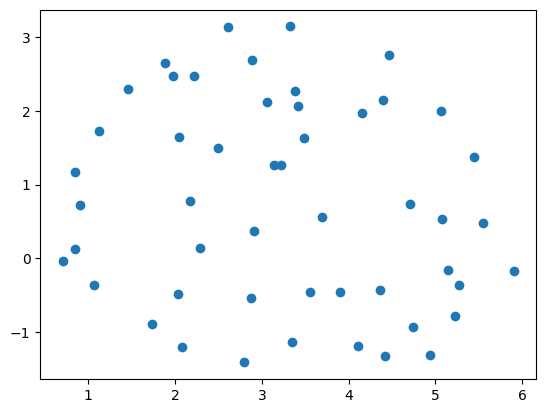

In [162]:
# projecting the skill embedding vectors to 2d dimension

from sklearn.manifold import TSNE
from umap import UMAP

# features = df.loc[:, :'petal_width']

# umap_2d = UMAP(n_components=2, n_neighbors=8, init='random', random_state=0)
# 
# X = umap_2d.fit_transform(X)

X_tsne = TSNE(init='pca').fit_transform(X)
import matplotlib.pyplot as plt

plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.show()

## Compute DBSCAN

One can access the labels assigned by :class:`~sklearn.cluster.DBSCAN` using
the `labels_` attribute. Noisy samples are given the label math:`-1`.



In [161]:
# trick to find the best value of epsilon for DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=17)
neighbors_fit = neighbors.fit(X_tsne)
distances, indices = neighbors_fit.kneighbors(X)
distances = numpy.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [154]:
# clustering of the tsne values
from sklearn import metrics
from sklearn.cluster import DBSCAN, KMeans 

db = KMeans(n_clusters=3).fit(X_tsne)
# db = DBSCAN(eps=0.5, min_samples=10).fit(X_tsne)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 0


Clustering algorithms are fundamentally unsupervised learning methods.
However, since :class:`~sklearn.datasets.make_blobs` gives access to the true
labels of the synthetic clusters, it is possible to use evaluation metrics
that leverage this "supervised" ground truth information to quantify the
quality of the resulting clusters. Examples of such metrics are the
homogeneity, completeness, V-measure, Rand-Index, Adjusted Rand-Index and
Adjusted Mutual Information (AMI).

If the ground truth labels are not known, evaluation can only be performed
using the model results itself. In that case, the Silhouette Coefficient comes
in handy.

For more information, see the
`sphx_glr_auto_examples_cluster_plot_adjusted_for_chance_measures.py`
example or the `clustering_evaluation` module.



In [27]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


## Plot results

Core samples (large dots) and non-core samples (small dots) are color-coded
according to the assigned cluster. Samples tagged as noise are represented in
black.



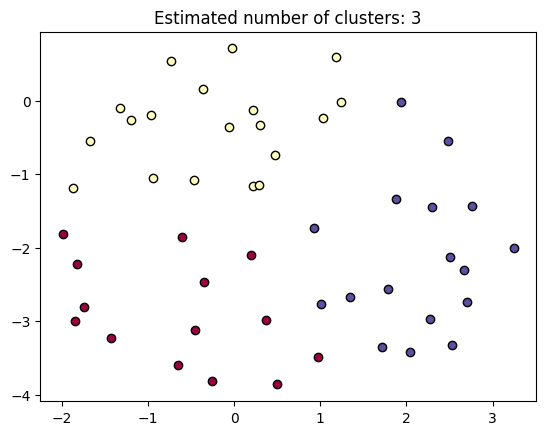

In [155]:
import matplotlib.pyplot as plt
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
# core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_tsne[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_tsne[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()


In [160]:
df_fig = df.copy()
df_fig['tsne-2d-one'] = X_tsne[:,0]
df_fig['tsne-2d-two'] = X_tsne[:,1]
df_orangecluster = df_fig.query('`tsne-2d-one` < 2').query('`tsne-2d-two` > -1.5')
# df_fig
df_orangecluster

,latent,action_0,action_1,action_2,action_3,action_4,action_5,tsne-2d-one,tsne-2d-two
1,"[tensor(-0.0244), tensor(0.0725), tensor(0.0227), tensor(-0.0291), tensor(0.0176), tensor(0.0733), tensor(-0.0003), tensor(0.0153)]",0.991304,0.000000,0.004348,0.004348,0.000000,0.000000,0.214596,-0.130086
2,"[tensor(0.0426), tensor(0.0401), tensor(0.0343), tensor(-0.0741), tensor(-0.0120), tensor(0.1121), tensor(-0.0577), tensor(0.0300)]",0.908333,0.027083,0.037500,0.008333,0.018750,0.000000,-0.019339,0.710340
3,"[tensor(0.0029), tensor(0.0926), tensor(-0.0152), tensor(-0.0123), tensor(-0.0349), tensor(-0.0483), tensor(0.0608), tensor(-0.0069)]",0.945833,0.016667,0.025000,0.008333,0.004167,0.000000,0.302114,-0.327873
4,"[tensor(-0.0310), tensor(0.0814), tensor(0.0247), tensor(-0.0102), tensor(-0.0112), tensor(0.0272), tensor(-0.0188), tensor(-0.0108)]",0.747059,0.198824,0.030588,0.007059,0.014118,0.002353,-0.055967,-0.358547
6,"[tensor(0.0684), tensor(0.0331), tensor(-0.0082), tensor(-0.0387), tensor(-0.0736), tensor(0.0878), tensor(0.0990), tensor(0.0477)]",0.994203,0.000000,0.004348,0.001449,0.000000,0.000000,1.180119,0.598756
7,"[tensor(-0.0149), tensor(0.0071), tensor(0.0523), tensor(-0.0800), tensor(0.0114), tensor(-0.0380), tensor(-0.0705), tensor(0.0740)]",0.992754,0.000000,0.002899,0.004348,0.000000,0.000000,-0.732475,0.533970
8,"[tensor(0.0759), tensor(0.0318), tensor(0.1219), tensor(-0.0011), tensor(-0.0276), tensor(0.0032), tensor(-0.0240), tensor(-0.0152)]",0.991304,0.000000,0.005797,0.001449,0.000000,0.001449,-1.669085,-0.547425
9,"[tensor(-0.0058), tensor(0.0408), tensor(0.0247), tensor(0.0044), tensor(0.0187), tensor(0.0604), tensor(0.0294), tensor(-0.0025)]",0.943750,0.014583,0.035417,0.000000,0.006250,0.000000,0.216507,-1.160447
10,"[tensor(0.0333), tensor(0.0833), tensor(0.0236), tensor(0.0244), tensor(-0.0156), tensor(0.0027), tensor(0.0467), tensor(-0.0608)]",0.929167,0.014583,0.018750,0.006250,0.031250,0.000000,-0.468402,-1.084514
12,"[tensor(-0.0056), tensor(0.0354), tensor(0.0859), tensor(0.0196), tensor(-0.0707), tensor(-0.0326), tensor(-0.0233), tensor(-0.0099)]",0.885714,0.063265,0.010204,0.004082,0.032653,0.004082,-0.960355,-0.194297
